# Train Script - MobileNetV2 + Transformer (BISINDO)

Replaces the old `train_mobile_net.ipynb`. Behaves the same way for the original baseline (just run all cells with the default `CONFIG` below), but the `CONFIG` cell now exposes the knobs needed for three of the paper's ablations:

To run a new ablation: change `CONFIG` in the cell below, give it a distinct `run_tag`, then **Run All**. Each run gets its own timestamped folder under `outputs/logs/mobile_net/` and its own row in `outputs/metrics/experiments.csv` -- nothing overwrites a previous run.

## Library Setup

In [1]:
# ================= STANDARD LIB =================
import os
import sys
import json
from datetime import datetime

# ================= THIRD PARTY =================
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.tensorboard import SummaryWriter

# ================= PATH SETUP =================
# Assumes this notebook's working directory is train/ (Jupyter's default),
# so the project root is one level up.
BASE_DIR = os.path.abspath("..")
sys.path.append(BASE_DIR)

# ================= LOCAL MODULE =================
from utils.dataloader import get_dataloader, get_transforms, get_class_weights
from utils.losses import FocalLoss
from utils.metrics import compute_metrics
from utils.experiment_logger import log_experiment
from models.mobile_net import MobileNetTransformer

print("BASE_DIR:", BASE_DIR)

BASE_DIR: D:\Softwares\AnacondaProjects\SignComparisonCNN


## Configuration

Edit this cell to switch between the baseline and any ablation, then **Run All**.

In [2]:
CONFIG = {
    # fine-tuning depth (fairness ablation) =====
    # 4       -> unfreeze only the last 4 of 19 top-level MobileNetV2 blocks
    #            (original MobileNetTransformer baseline).
    # "full"  -> fully unfreeze the backbone, matching CNN_LSTM's original
    #            fine-tuning depth for a fairness-matched ablation.
    # 0       -> freeze the entire backbone (pure feature extractor).
    "unfreeze_blocks": "full",

    # ===== pooling ablation =====
    # "last"      -> original baseline: only the final timestep's output.
    # "mean"      -> average over all timesteps.
    # "attention" -> Bahdanau-style attention pooling (same form as CNN_LSTM).
    "pooling": "last",

    # Number of Transformer encoder layers (original baseline checkpoint used 4).
    "transformer_layers": 4,

    # ===== motion representation ablation =====
    # "diff"         -> normalized-RGB frame differencing (original baseline).
    # "optical_flow" -> dense Farneback optical flow on raw grayscale frames.
    "motion_mode": "diff",

    # Suffix appended to the run folder name and experiment name, e.g.
    # "pool-mean" or "unfreeze-full". Leave empty for a plain run_<timestamp> name.
    "run_tag": "unfreeze-full",

    # ===== Standard training hyperparameters (original baseline values) =====
    "epochs": 50,
    "batch_size": 8,
    "lr": 3e-5,
    "weight_decay": 1e-5,
    "focal_gamma": 2.0,
    "grad_clip": 5.0,
    "early_stop_patience": 3,
    "scheduler_patience": 1,
    "scheduler_factor": 0.5,
    "seq_len": 20,
    "seed": 42,
    # num_workers only affects how many parallel processes read/preprocess
    # frames from disk -- it does NOT touch gradients, batch composition, or
    # anything the model learns, so raising it is safe even though
    # CNN_LSTM's baseline run already finished with num_workers=4. batch_size
    # is intentionally left at 8 (unchanged) to stay fair with that baseline,
    # since batch_size DOES affect gradient noise/training dynamics.
    "num_workers": 8,

    # Speed-only: trains in mixed precision (fp16 compute + fp32 master
    # weights via torch.amp.autocast/GradScaler) when running on CUDA. This
    # was added specifically because MobileNetTransformer wall-clock training
    # time was a practical bottleneck (the baseline run took the full 50
    # epochs). Effect on results: forward/backward matmuls run in fp16, which
    # is numerically slightly different from full fp32 (typically negligible
    # for final accuracy, occasionally marginally better due to implicit
    # regularization) but is NOT bit-identical to the two preserved fp32
    # baseline runs -- this is a deliberate, documented protocol deviation
    # traded for speed, not a fairness-ablation variable. No effect on CPU
    # (autocast/GradScaler are no-ops when enabled=False).
    "use_amp": True,
}

print(json.dumps(CONFIG, indent=2))

{
  "unfreeze_blocks": "full",
  "pooling": "last",
  "transformer_layers": 4,
  "motion_mode": "diff",
  "run_tag": "unfreeze-full",
  "epochs": 50,
  "batch_size": 8,
  "lr": 3e-05,
  "weight_decay": 1e-05,
  "focal_gamma": 2.0,
  "grad_clip": 5.0,
  "early_stop_patience": 3,
  "scheduler_patience": 1,
  "scheduler_factor": 0.5,
  "seq_len": 20,
  "seed": 42,
  "num_workers": 8,
  "use_amp": true
}


## Setup Train Path

In [3]:
train_path = os.path.join(BASE_DIR, "data/WLBisindo/split/train")
val_path   = os.path.join(BASE_DIR, "data/WLBisindo/split/val")
test_path  = os.path.join(BASE_DIR, "data/WLBisindo/split/test")

for p, name in [(train_path, "train"), (val_path, "val"), (test_path, "test")]:
    print(f"{name} exists:", os.path.exists(p))

train exists: True
val exists: True
test exists: True


## Call Dataloader for Training

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
# Speed-only: lets cuDNN auto-tune the fastest conv algorithm for our fixed
# (batch_size, 6, 224, 224) input shape. Safe here because every batch has
# the same shape -- no effect on training results, just faster convolutions
# on GPU after a brief warmup on the first batch.
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

train_transform, val_transform = get_transforms()

train_loader, train_dataset = get_dataloader(
    train_path,
    batch_size=CONFIG["batch_size"],
    transform=train_transform,
    use_weighted_sampler=True,
    seq_len=CONFIG["seq_len"],
    motion_mode=CONFIG["motion_mode"],
    num_workers=CONFIG["num_workers"],
)

val_loader, val_dataset = get_dataloader(
    val_path,
    batch_size=CONFIG["batch_size"],
    transform=val_transform,
    use_weighted_sampler=False,
    seq_len=CONFIG["seq_len"],
    motion_mode=CONFIG["motion_mode"],
    num_workers=CONFIG["num_workers"],
)

test_loader, test_dataset = get_dataloader(
    test_path,
    batch_size=CONFIG["batch_size"],
    transform=val_transform,
    use_weighted_sampler=False,
    seq_len=CONFIG["seq_len"],
    motion_mode=CONFIG["motion_mode"],
    num_workers=CONFIG["num_workers"],
)

NUM_CLASSES = len(train_dataset.label_map)
idx_to_name = {idx: name for name, idx in train_dataset.label_map.items()}
CLASS_NAMES = [idx_to_name[i] for i in range(NUM_CLASSES)]

print("Num classes:", NUM_CLASSES)
print("Train/Val/Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))

Device: cuda
Class counts: [34 14 32 35 23 30 34 28 13 35 27 32 34 12 21 28 24 29 32 28 25 22 31 14
 35 33 30 26 35 33 32 32]
Num classes: 32
Train/Val/Test sizes: 893 182 223


## Check Shape and Labels

In [5]:
for x, y in train_loader:
    print("Input shape :", x.shape)  # (B, seq_len, 6, 224, 224)
    print("Label shape :", y.shape)  # (B,)
    print("Label sample:", y[:5])
    break

Input shape : torch.Size([8, 20, 6, 224, 224])
Label shape : torch.Size([8])
Label sample: tensor([ 2,  3,  1, 16, 15])


## Setup Experiment Log Dir

In [6]:
def build_run_name(config):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    if config["run_tag"]:
        return f"run_{timestamp}_{config['run_tag']}"
    return f"run_{timestamp}"

RUN_NAME = build_run_name(CONFIG)
LOG_DIR = os.path.join(BASE_DIR, "outputs/logs/mobile_net", RUN_NAME)
os.makedirs(LOG_DIR, exist_ok=True)

log_file = os.path.join(LOG_DIR, "log.txt")

def log_message(msg):
    print(msg)
    with open(log_file, "a") as f:
        f.write(msg + "\n")

writer = SummaryWriter(LOG_DIR)
print("Log dir:", LOG_DIR)

Log dir: D:\Softwares\AnacondaProjects\SignComparisonCNN\outputs/logs/mobile_net\run_20260917_125323_unfreeze-full


## Build Model & Set Fine-Tuning Depth

In [7]:
model = MobileNetTransformer(
    num_classes=NUM_CLASSES,
    seq_len=CONFIG["seq_len"],
    num_layers=CONFIG["transformer_layers"],
    pooling=CONFIG["pooling"],
)

unfreeze_blocks = None if CONFIG["unfreeze_blocks"] in ("full", None) else int(CONFIG["unfreeze_blocks"])
total_blocks = model.encoder.set_trainable_blocks(unfreeze_blocks)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

log_message(f"Backbone top-level blocks: {total_blocks}; unfreeze_blocks={CONFIG['unfreeze_blocks']}")
log_message(f"Pooling: {CONFIG['pooling']}; transformer_layers: {CONFIG['transformer_layers']}")
log_message(f"Trainable params: {trainable:,} / {total:,}")

Backbone top-level blocks: 19; unfreeze_blocks=full
Pooling: last; transformer_layers: 4
Trainable params: 15,640,960 / 15,640,960


## Loss, Optimizer, Scheduler

In [8]:
class_weights = get_class_weights(train_dataset, device)
criterion = FocalLoss(alpha=class_weights, gamma=CONFIG["focal_gamma"])

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=CONFIG["scheduler_patience"],
    factor=CONFIG["scheduler_factor"],
)

Class weights: tensor([0.7489, 1.8187, 0.7957, 0.7275, 1.1071, 0.8487, 0.7489, 0.9094, 1.9586,
        0.7275, 0.9430, 0.7957, 0.7489, 2.1219, 1.2125, 0.9094, 1.0609, 0.8780,
        0.7957, 0.9094, 1.0185, 1.1574, 0.8214, 1.8187, 0.7275, 0.7716, 0.8487,
        0.9793, 0.7275, 0.7716, 0.7957, 0.7957], device='cuda:0')


In [9]:
config_to_save = dict(CONFIG)
config_to_save.update({
    "model": "MobileNetTransformer",
    "run_name": RUN_NAME,
    "num_classes": NUM_CLASSES,
    "total_backbone_blocks": total_blocks,
    "trainable_params": trainable,
    "total_params": total,
})

with open(os.path.join(LOG_DIR, "config.json"), "w") as f:
    json.dump(config_to_save, f, indent=4)

print(json.dumps(config_to_save, indent=2))

{
  "unfreeze_blocks": "full",
  "pooling": "last",
  "transformer_layers": 4,
  "motion_mode": "diff",
  "run_tag": "unfreeze-full",
  "epochs": 50,
  "batch_size": 8,
  "lr": 3e-05,
  "weight_decay": 1e-05,
  "focal_gamma": 2.0,
  "grad_clip": 5.0,
  "early_stop_patience": 3,
  "scheduler_patience": 1,
  "scheduler_factor": 0.5,
  "seq_len": 20,
  "seed": 42,
  "num_workers": 8,
  "use_amp": true,
  "model": "MobileNetTransformer",
  "run_name": "run_20260917_125323_unfreeze-full",
  "num_classes": 32,
  "total_backbone_blocks": 19,
  "trainable_params": 15640960,
  "total_params": 15640960
}


# Training Process

## Train Run Script

TensorBoard logs (`Loss/train`, `Loss/val`, `Accuracy/train`, `Accuracy/val`, `Overfitting/gap`, `LR`, plus `Weights/*` and `Grads/*` histograms) are flushed to disk at the end of every epoch, so `tensorboard --logdir=outputs/logs` shows live progress while this cell is still running, and nothing is lost if training is interrupted.

In [10]:
best_val_loss = float("inf")
counter = 0

# Speed-only: see CONFIG["use_amp"] comment above.
use_amp = CONFIG["use_amp"] and device.type == "cuda"
scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)
log_message(f"Mixed precision (AMP) enabled: {use_amp}")

try:
    for epoch in range(CONFIG["epochs"]):
        log_message(f"\nEpoch {epoch + 1}/{CONFIG['epochs']}")

        # ===== TRAIN =====
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        train_bar = tqdm(train_loader, desc="Training", leave=False)
        for x, y in train_bar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(x)
                loss = criterion(outputs, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)
            train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss /= max(1, len(train_loader))
        train_acc = train_correct / max(1, train_total)

        # ===== VALIDATION =====
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_bar = tqdm(val_loader, desc="Validation", leave=False)
        with torch.no_grad():
            for x, y in val_bar:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    outputs = model(x)
                    loss = criterion(outputs, y)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        val_loss /= max(1, len(val_loader))
        val_acc = val_correct / max(1, val_total)

        # ===== TENSORBOARD LOGGING (train + val) =====
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)
        writer.add_scalar("Overfitting/gap", train_acc - val_acc, epoch)
        current_lr = optimizer.param_groups[0]["lr"]
        writer.add_scalar("LR", current_lr, epoch)
        for name, param in model.named_parameters():
            writer.add_histogram(f"Weights/{name}", param, epoch)
            if param.grad is not None:
                writer.add_histogram(f"Grads/{name}", param.grad, epoch)
        writer.flush()

        log_message(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        log_message(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
        log_message(f"LR: {current_lr}")
        log_message("-" * 40)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), os.path.join(LOG_DIR, "best_model.pth"))
            log_message("Best model saved!")
        else:
            counter += 1
            log_message(f"EarlyStopping counter: {counter}/{CONFIG['early_stop_patience']}")
            if counter >= CONFIG["early_stop_patience"]:
                log_message("Early stopping triggered!")
                break

    torch.save(model.state_dict(), os.path.join(LOG_DIR, "last_model.pth"))
finally:
    writer.flush()
    writer.close()

Mixed precision (AMP) enabled: True

Epoch 1/50


Train Loss: 3.2525 | Acc: 0.0392
Val   Loss: 2.8375 | Acc: 0.0495
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 2/50


Train Loss: 3.0834 | Acc: 0.0470
Val   Loss: 2.7827 | Acc: 0.0440
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 3/50


Train Loss: 2.9697 | Acc: 0.0862
Val   Loss: 2.6502 | Acc: 0.0824
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 4/50


Train Loss: 2.8210 | Acc: 0.1299
Val   Loss: 2.4583 | Acc: 0.1044
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 5/50


...

Train Loss: 0.2196 | Acc: 0.8544
Val   Loss: 0.3429 | Acc: 0.8846
LR: 1.5e-05
----------------------------------------
EarlyStopping counter: 2/3

Epoch 26/50


Train Loss: 0.2028 | Acc: 0.8746
Val   Loss: 0.3054 | Acc: 0.8956
LR: 7.5e-06
----------------------------------------
Best model saved!

Epoch 27/50


Train Loss: 0.1888 | Acc: 0.8824
Val   Loss: 0.3258 | Acc: 0.8901
LR: 7.5e-06
----------------------------------------
EarlyStopping counter: 1/3

Epoch 28/50


Train Loss: 0.1649 | Acc: 0.8981
Val   Loss: 0.3143 | Acc: 0.8901
LR: 7.5e-06
----------------------------------------
EarlyStopping counter: 2/3

Epoch 29/50


Train Loss: 0.1653 | Acc: 0.8903
Val   Loss: 0.3152 | Acc: 0.8901
LR: 3.75e-06
----------------------------------------
EarlyStopping counter: 3/3
Early stopping triggered!


## Final Evaluation (reload best checkpoint)

In [11]:
model.load_state_dict(torch.load(os.path.join(LOG_DIR, "best_model.pth"), map_location=device, weights_only=True))
model.eval()
print("Best model reloaded for final evaluation.")

Best model reloaded for final evaluation.


In [12]:
def evaluate_split(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
    return np.array(y_true), np.array(y_pred), compute_metrics(y_true, y_pred)

In [13]:
_, val_pred, val_metrics = evaluate_split(model, val_loader, device)
print("Validation metrics (best checkpoint):")
print(json.dumps(val_metrics, indent=2))

with open(os.path.join(LOG_DIR, "evaluation.json"), "w") as f:
    json.dump(val_metrics, f, indent=4)

Validation metrics (best checkpoint):
{
  "accuracy": 0.8901098901098901,
  "precision": 0.9042782738095239,
  "recall": 0.8681547619047618,
  "f1": 0.8698552366750896,
  "hamming_loss": 0.10989010989010989
}


In [14]:
test_true, test_pred, test_metrics = evaluate_split(model, test_loader, device)
print("Test metrics (best checkpoint):")
print(json.dumps(test_metrics, indent=2))

with open(os.path.join(LOG_DIR, "test_eval.json"), "w") as f:
    json.dump(test_metrics, f, indent=4)

Test metrics (best checkpoint):
{
  "accuracy": 0.8968609865470852,
  "precision": 0.9033482142857143,
  "recall": 0.8970238095238094,
  "f1": 0.8898759022839905,
  "hamming_loss": 0.1031390134529148
}


## Classification Report & Confusion Matrix

In [15]:
report_text = classification_report(
    test_true, test_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
)
print(report_text)

with open(os.path.join(LOG_DIR, "classification_report.txt"), "w") as f:
    f.write(report_text)

              precision    recall  f1-score   support

         air       1.00      0.88      0.93         8
         apa       0.80      1.00      0.89         4
   bagaimana       1.00      1.00      1.00         8
     belajar       1.00      0.62      0.77         8
   berangkat       0.86      1.00      0.92         6
        cari       0.78      0.88      0.82         8
      datang       0.88      0.88      0.88         8
      dengar       0.88      1.00      0.93         7
     di_mana       0.75      0.75      0.75         4
        hari       1.00      1.00      1.00         8
       hijau       1.00      1.00      1.00         7
       hitam       1.00      1.00      1.00         8
       ingat       0.70      0.88      0.78         8
       kapan       1.00      1.00      1.00         4
    keluarga       0.80      0.80      0.80         5
      kuning       1.00      0.86      0.92         7
        lagi       1.00      1.00      1.00         6
        maaf       1.00    

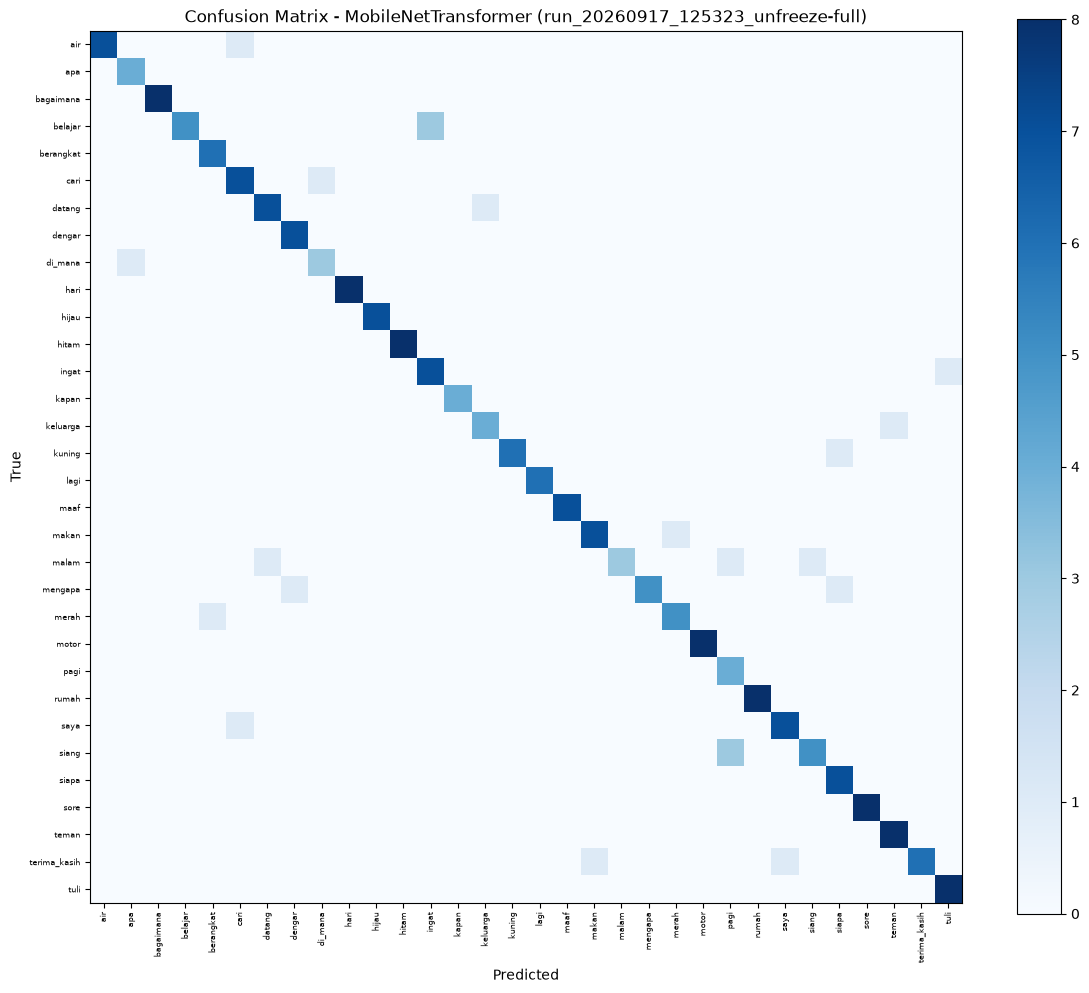

In [16]:
cm = confusion_matrix(test_true, test_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
ax.set_yticklabels(CLASS_NAMES, fontsize=6)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix - MobileNetTransformer ({RUN_NAME})")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(LOG_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

## Log Experiment

In [17]:
exp_model_name = (
    "MobileNetTransformer_"
    + ("unfreeze-full" if unfreeze_blocks is None else f"unfreeze-{unfreeze_blocks}")
    + f"_pool-{CONFIG['pooling']}_motion-{CONFIG['motion_mode']}"
)
if CONFIG["run_tag"]:
    exp_model_name += f"_{CONFIG['run_tag']}"

log_experiment(test_metrics, exp_model_name, os.path.join(BASE_DIR, "outputs/metrics"))
print("Done. Run artifacts saved to:", LOG_DIR)

Experiment logged to: D:\Softwares\AnacondaProjects\SignComparisonCNN\outputs/metrics\experiments.csv
Done. Run artifacts saved to: D:\Softwares\AnacondaProjects\SignComparisonCNN\outputs/logs/mobile_net\run_20260917_125323_unfreeze-full
